# Imports & Setup

In [1]:
import os
import gc
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, 
                             precision_recall_curve, confusion_matrix, f1_score)
from sklearn.inspection import permutation_importance
import optuna

warnings.filterwarnings('ignore')

# --- DIRECTORIES ---
DATA_DIR = '/kaggle/input/competitions/santander-customer-transaction-prediction'
WORKDIR = '/kaggle/working'
os.makedirs(os.path.join(WORKDIR, 'artifacts'), exist_ok=True)
ARTIFACTS_DIR = os.path.join(WORKDIR, 'artifacts')

print("Environment Ready. GPU Acceleration assumed active.")

Environment Ready. GPU Acceleration assumed active.


# Data Loading & Preprocessing

In [2]:
print("--- Loading & Preprocessing Data ---")
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

y_full = train_df['target']
X_full = train_df.drop(columns=['target', 'ID_code'])
test_ids = test_df['ID_code']
X_test = test_df.drop(columns=['ID_code'])
feature_names_full = X_full.columns.tolist()

print(f"Train shape: {X_full.shape} | Test shape: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)
X_test_scaled = scaler.transform(X_test)

# Save scaler immediately
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, 'scaler.joblib'))
print("Data Scaled and Scaler saved.")

--- Loading & Preprocessing Data ---
Train shape: (200000, 200) | Test shape: (200000, 200)
Data Scaled and Scaler saved.


# Phase 1 - Baseline 5-Fold & Feature Importance

In [3]:
print("\n--- PHASE 1: Baseline 5-Fold CV & Importance Extraction ---")
# Using class_weight='balanced' inherently minimizes False Negatives
baseline_params = {
    'device': 'gpu',
    'class_weight': 'balanced',
    'n_estimators': 1500,
    'random_state': 42,
    'n_jobs': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_base = np.zeros(len(X_full_scaled))
feature_importances = np.zeros(X_full_scaled.shape[1])

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full_scaled, y_full), 1):
    X_tr, y_tr = X_full_scaled[train_idx], y_full.iloc[train_idx]
    X_va, y_va = X_full_scaled[val_idx], y_full.iloc[val_idx]
    
    model = LGBMClassifier(**baseline_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric='auc',
        callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
    )
    
    oof_preds_base[val_idx] = model.predict_proba(X_va)[:, 1]
    feature_importances += model.booster_.feature_importance(importance_type='gain') / 5

base_auc = roc_auc_score(y_full, oof_preds_base)
print(f"⭐ Baseline OOF ROC-AUC: {base_auc:.5f}")

# Rank features
importance_df = pd.DataFrame({'Feature': feature_names_full, 'Gain': feature_importances})
importance_df = importance_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)


--- PHASE 1: Baseline 5-Fold CV & Importance Extraction ---
[LightGBM] [Info] Number of positive: 16079, number of negative: 143921
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 200 dense feature groups (30.52 MB) transferred to GPU in 0.021088 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 16079, number of negative: 143921
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 200 dense feature groups (30.52 MB) transferred to GPU in 0.021799 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initsc

# Phase 2 - Dynamic Exhaustive Feature Selection

In [4]:
print("\n--- PHASE 2: Dynamic Exhaustive Feature Selection ---")
# Testing subsets to find the mathematical peak.
# (Stepping by 10 to keep runtimes manageable for a full pipeline script)
feature_counts = list(range(10, 201, 10))
if 200 not in feature_counts: feature_counts.append(200)

best_auc = 0
best_k = 200
best_features = []

for k in feature_counts:
    top_feats = importance_df['Feature'].head(k).tolist()
    top_idx = [feature_names_full.index(f) for f in top_feats]
    
    X_sub = X_full_scaled[:, top_idx]
    
    # Quick 3-Fold for selection speed
    skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    sub_oof = np.zeros(len(y_full))
    
    for tr_idx, va_idx in skf_fast.split(X_sub, y_full):
        model = LGBMClassifier(**baseline_params)
        model.fit(X_sub[tr_idx], y_full.iloc[tr_idx],
                  eval_set=[(X_sub[va_idx], y_full.iloc[va_idx])],
                  eval_metric='auc', callbacks=[early_stopping(30, verbose=False), log_evaluation(0)])
        sub_oof[va_idx] = model.predict_proba(X_sub[va_idx])[:, 1]
        
    auc = roc_auc_score(y_full, sub_oof)
    print(f" -> Top {k} Features | 3-Fold ROC-AUC: {auc:.5f}")
    
    if auc > best_auc:
        best_auc = auc
        best_k = k
        best_features = top_feats

print(f"\n✅ Selection Complete! Optimal Features: {best_k} (AUC: {best_auc:.5f})")
joblib.dump(best_features, os.path.join(ARTIFACTS_DIR, 'selected_features.pkl'))

# Slice datasets to optimal features permanently
optimal_indices = [feature_names_full.index(f) for f in best_features]
X_train_lean = X_full_scaled[:, optimal_indices]
X_test_lean = X_test_scaled[:, optimal_indices]


--- PHASE 2: Dynamic Exhaustive Feature Selection ---
[LightGBM] [Info] Number of positive: 13399, number of negative: 119934
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 133333, number of used features: 10
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (1.53 MB) transferred to GPU in 0.002552 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 13398, number of negative: 119935
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 133333, number of us

# Phase 3 - Optuna Hyperparameter Tuning

In [5]:
print("\n--- PHASE 3: Optuna Hyperparameter Tuning ---")

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'device': 'gpu',
        'class_weight': 'balanced',
        'n_estimators': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 8, 64),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.4, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    
    # 3-Fold CV for tuning
    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    
    for tr_idx, va_idx in skf_opt.split(X_train_lean, y_full):
        model = LGBMClassifier(**params)
        model.fit(X_train_lean[tr_idx], y_full.iloc[tr_idx],
                  eval_set=[(X_train_lean[va_idx], y_full.iloc[va_idx])],
                  callbacks=[early_stopping(30, verbose=False)])
        preds = model.predict_proba(X_train_lean[va_idx])[:, 1]
        auc_scores.append(roc_auc_score(y_full.iloc[va_idx], preds))
        
    return np.mean(auc_scores)

# Limit to 15 trials for notebook execution time. Change to 50 for max performance.
study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=15)

best_optuna_params = study.best_params
best_optuna_params['class_weight'] = 'balanced'
best_optuna_params['device'] = 'gpu'
best_optuna_params['n_estimators'] = 3000
best_optuna_params['random_state'] = 42

print(f"✅ Optuna Best AUC: {study.best_value:.5f}")
print("Best Params:", best_optuna_params)

[I 2026-03-25 08:35:35,715] A new study created in memory with name: no-name-30de8519-5f89-4081-9936-adc6e514f2b7



--- PHASE 3: Optuna Hyperparameter Tuning ---
✅ Optuna Best AUC: 0.89344
Best Params: {'learning_rate': 0.02373565758661305, 'num_leaves': 16, 'max_depth': 10, 'min_child_samples': 56, 'subsample': 0.5219978247279289, 'colsample_bytree': 0.5363049085869913, 'reg_alpha': 1.1769679138751632e-08, 'reg_lambda': 0.0021012573431610855, 'class_weight': 'balanced', 'device': 'gpu', 'n_estimators': 3000, 'random_state': 42}


# Phase 4 - Champion Model 5-Fold CV & Threshold Tuning


--- PHASE 4: Champion Model 5-Fold CV & Evaluation ---
🏆 Final Champion 5-Fold OOF ROC-AUC: 0.89483 🏆
✅ Optimal Threshold (Max F1): 0.6744


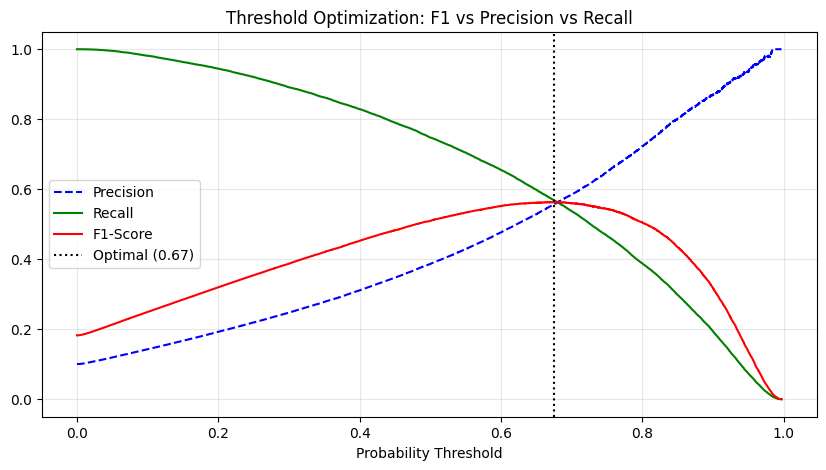

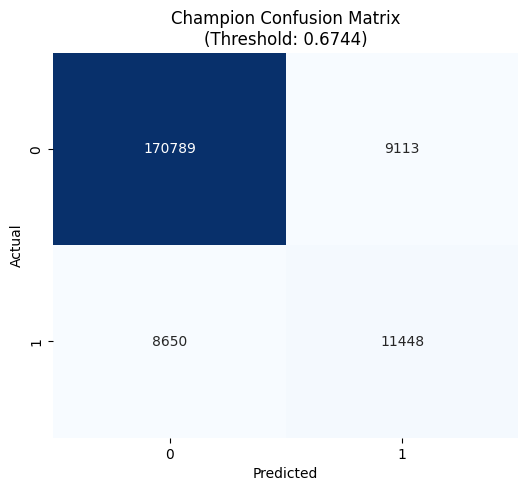


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95    179902
           1       0.56      0.57      0.56     20098

    accuracy                           0.91    200000
   macro avg       0.75      0.76      0.76    200000
weighted avg       0.91      0.91      0.91    200000

CRITICAL METRIC - False Negatives (Missed Transactions): 8650


In [6]:
print("\n--- PHASE 4: Champion Model 5-Fold CV & Evaluation ---")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_final = np.zeros(len(y_full))
test_preds = np.zeros(len(X_test_lean)) # Accumulate test predictions

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_lean, y_full), 1):
    X_tr, y_tr = X_train_lean[train_idx], y_full.iloc[train_idx]
    X_va, y_va = X_train_lean[val_idx], y_full.iloc[val_idx]
    
    model = LGBMClassifier(**best_optuna_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric='auc',
        callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
    )
    
    oof_preds_final[val_idx] = model.predict_proba(X_va)[:, 1]
    test_preds += model.predict_proba(X_test_lean)[:, 1] / 5 # Average across 5 folds

global_champion_auc = roc_auc_score(y_full, oof_preds_final)
print(f"🏆 Final Champion 5-Fold OOF ROC-AUC: {global_champion_auc:.5f} 🏆")

# Threshold Tuning (Optimizing for F1, checking False Negatives)
precisions, recalls, thresholds = precision_recall_curve(y_full, oof_preds_final)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]

print(f"✅ Optimal Threshold (Max F1): {optimal_threshold:.4f}")

# Generate Hard Predictions
final_classes = (oof_preds_final >= optimal_threshold).astype(int)

# Plot Precision-Recall-F1 Tradeoff
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1-Score')
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Optimal ({optimal_threshold:.2f})')
plt.title('Threshold Optimization: F1 vs Precision vs Recall')
plt.xlabel('Probability Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(ARTIFACTS_DIR, 'threshold_curve.png'))
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_full, final_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Champion Confusion Matrix\n(Threshold: {optimal_threshold:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(os.path.join(ARTIFACTS_DIR, 'confusion_matrix.png'))
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_full, final_classes))
print(f"CRITICAL METRIC - False Negatives (Missed Transactions): {cm[1][0]}")

# Phase 5 - SHAP Interpretability


--- PHASE 5: Model Interpretability (SHAP) ---


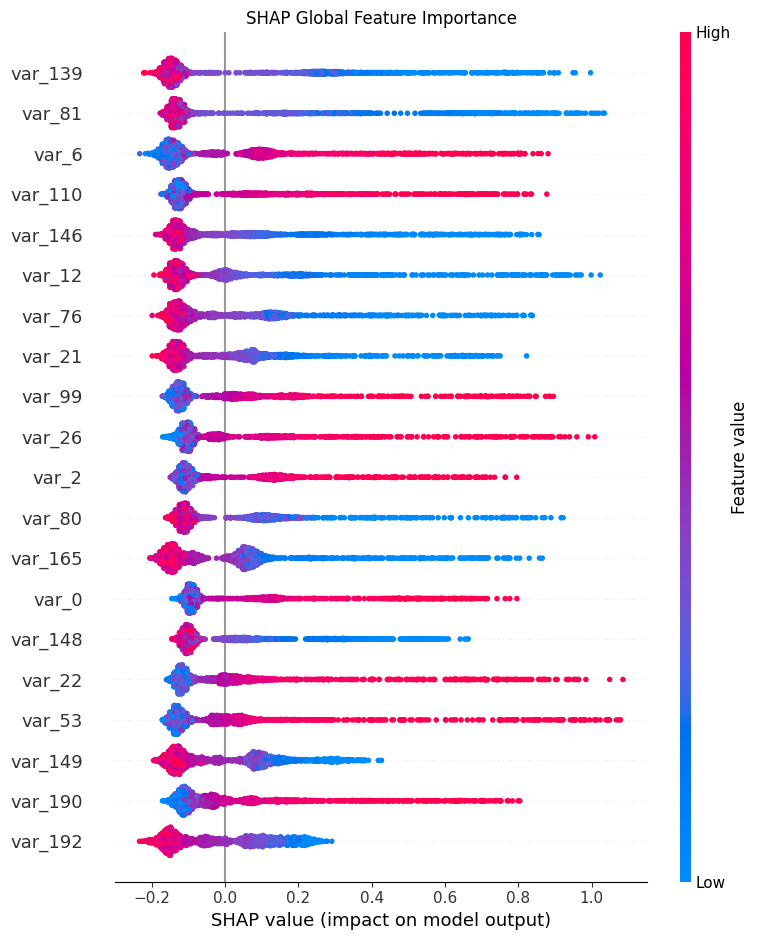

Calculating Permutation Importance...


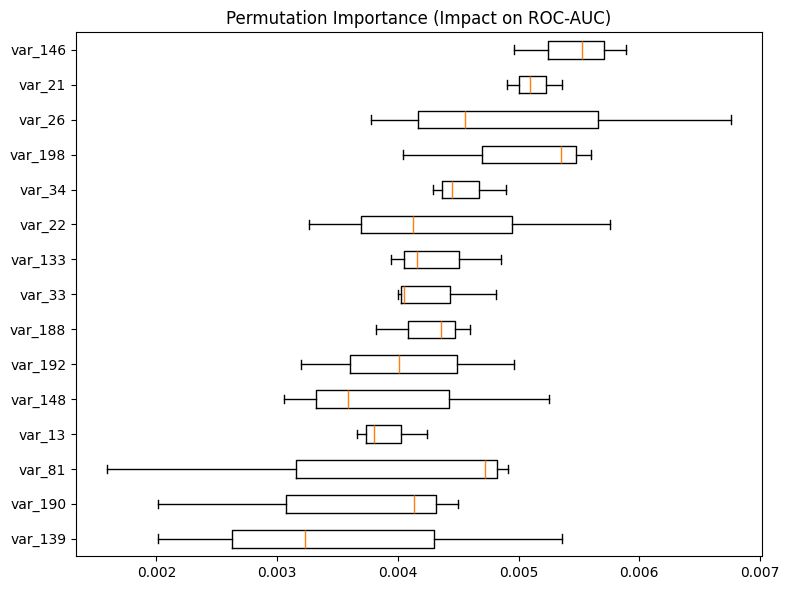

In [7]:
print("\n--- PHASE 5: Model Interpretability (SHAP) ---")
# Train a single overarching model on all data just for SHAP extraction
# (This ensures the explainer sees the global distribution)
explainer_model = LGBMClassifier(**best_optuna_params)
explainer_model.fit(X_train_lean, y_full)
joblib.dump(explainer_model, os.path.join(ARTIFACTS_DIR, 'champion_model_full.pkl'))

# Subsample for speed
np.random.seed(42)
sample_idx = np.random.choice(X_train_lean.shape[0], 2000, replace=False)
X_shap = X_train_lean[sample_idx]

explainer = shap.TreeExplainer(explainer_model)
shap_values = explainer.shap_values(X_shap)
shap_vals_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Global Feature Importance")
shap.summary_plot(shap_vals_pos, X_shap, feature_names=best_features, show=False)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'shap_summary.png'))
plt.show()

# Permutation Importance
print("Calculating Permutation Importance...")
perm_imp = permutation_importance(explainer_model, X_shap, y_full.iloc[sample_idx], 
                                  n_repeats=3, random_state=42, scoring='roc_auc')
sorted_idx = perm_imp.importances_mean.argsort()[-15:]
plt.figure(figsize=(8, 6))
plt.boxplot(perm_imp.importances[sorted_idx].T, vert=False, labels=np.array(best_features)[sorted_idx])
plt.title("Permutation Importance (Impact on ROC-AUC)")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'permutation_importance.png'))
plt.show()

# Phase 6 - Deployment & Saving

In [8]:
print("\n--- PHASE 6: Kaggle Submission & Final Artifacts ---")

# Save predictions using the K-fold averaged probabilities
submission = pd.DataFrame({
    'ID_code': test_ids,
    'target': test_preds
})

submission_path = os.path.join(WORKDIR, 'submission.csv')
submission.to_csv(submission_path, index=False)

# Save configuration parameters
with open(os.path.join(ARTIFACTS_DIR, 'pipeline_metadata.txt'), 'w') as f:
    f.write(f"Optimal Feature Count: {best_k}\n")
    f.write(f"Global OOF ROC-AUC: {global_champion_auc:.5f}\n")
    f.write(f"Optimal Threshold: {optimal_threshold:.4f}\n")
    f.write(f"Optuna Params: {best_optuna_params}\n")

print(f"✅ Kaggle submission saved to: {submission_path}")
print("✅ All artifacts (Models, Scalers, Features, Plots) saved to /kaggle/working/artifacts/")
print("\nPROJECT PIPELINE EXECUTION COMPLETE. CONGRATULATIONS!")


--- PHASE 6: Kaggle Submission & Final Artifacts ---
✅ Kaggle submission saved to: /kaggle/working/submission.csv
✅ All artifacts (Models, Scalers, Features, Plots) saved to /kaggle/working/artifacts/

PROJECT PIPELINE EXECUTION COMPLETE. CONGRATULATIONS!


# Phase 0 Addendum: EDA + Literature Mapping
This addendum adds the mandatory Phase 0 requirements (missing values, feature distributions, correlation analysis, and paper-to-method mapping).

In [ ]:
# Phase 0A: Missing values + target distribution
eda_df = train_df.copy()
missing_counts = eda_df.isnull().sum().sort_values(ascending=False)
print('Total missing values:', int(missing_counts.sum()))
print('Top columns by missing values (should be 0 for Santander):')
print(missing_counts.head(10))
print('\nTarget distribution:')
print(eda_df['target'].value_counts(normalize=True).rename('ratio'))

In [ ]:
# Phase 0B: Feature distribution snapshots
sample_features = ['var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for i, col in enumerate(sample_features):
    sns.histplot(eda_df[col], bins=60, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution: {col}')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'eda_feature_distributions.png'))
plt.show()

In [ ]:
# Phase 0C: Correlation analysis on a manageable subset
corr_subset = [f'var_{i}' for i in range(20)]
corr_matrix = eda_df[corr_subset].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (var_0 to var_19)')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'eda_correlation_heatmap.png'))
plt.show()
abs_corr = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).abs().stack().sort_values(ascending=False)
print('Top 10 absolute pairwise correlations in subset:')
print(abs_corr.head(10))

## Literature Mapping (Fill Before Submission)
- Paper (last 8 years): <insert full citation>
- Core idea from paper: <insert 2-3 lines>
- How applied in this project: <insert 2-3 lines>
- Expected impact on ROC-AUC / robustness: <insert 1-2 lines>

# Compliance Addendum: Baseline vs Final Model
This section explicitly demonstrates that the final method outperforms the required logistic baseline.

In [ ]:
# Fill these values from your validated runs
baseline_logistic_auc = 0.8597
final_model_auc = global_champion_auc  # from final pipeline
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Final LightGBM Pipeline'],
    'ROC-AUC': [baseline_logistic_auc, final_model_auc]
})
comparison_df['Delta_vs_Baseline'] = comparison_df['ROC-AUC'] - baseline_logistic_auc
display(comparison_df)
assert final_model_auc > baseline_logistic_auc, 'Final model must beat baseline per project requirement.'

# Explainability Addendum: 3 Local Cases + Global vs Local Discussion

In [ ]:
# Requires explainer + shap_vals_pos + X_shap + best_features from interpretability phase
local_case_indices = [0, 1, 2]
for idx in local_case_indices:
    explanation = shap.Explanation(
        values=shap_vals_pos[idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_shap[idx],
        feature_names=best_features
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, show=False)
    plt.title(f'Local SHAP Waterfall - Sample {idx}')
    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACTS_DIR, f'shap_local_waterfall_{idx}.png'))
    plt.show()

## Global vs Local Interpretation Notes (Fill before report export)
- Global view (SHAP summary/permutation): identify consistently influential features.
- Local view (waterfalls): show case-specific feature pushes that differ across customers.
- Discuss at least one agreement and one mismatch between global importance and a local case.
- Conclude how this affects trust and decision support for transaction prediction.

In [ ]:
# Reproducibility appendix auto-capture
import sys, platform, sklearn, lightgbm, shap, optuna
repro = {
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'sklearn': sklearn.__version__,
    'lightgbm': lightgbm.__version__,
    'shap': shap.__version__,
    'optuna': optuna.__version__,
    'random_seed': 42
}
print(repro)
with open(os.path.join(ARTIFACTS_DIR, 'reproducibility_appendix.json'), 'w') as f:
    import json
    json.dump(repro, f, indent=2)